In [9]:
import scanpy as sc
import sys
import sys
sys.path.append('/Users/amossi/Documents/code')
from scipy.spatial import KDTree
import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYPR1',
    'WR 8':'WR HYPR2',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    'nIPC-RG-like':'RG-like',
 
}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])
adata.obs['m-states'] = pd.Categorical(['Mural' if m.count('Mural') else m for m in adata.obs['m-states']])

# All Samples

In [24]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'

    'WR Endo.Ass.':'#e76d89',# Deep cerise
    'WR Periphery1':'#e76d89',# Deep cerise
    'WR Periphery2':'#e76d89',# Deep cerise
    'WR Periphery3':'#e76d89',# Deep cerise
    'WR HYPR1':'#e76d89',# Deep cerise
    'WR HYPR2':'#e76d89',# Deep cerise
    'WR nIPC':'#e76d89',# Deep cerise
    'WR OPC':'#e76d89',# Deep cerise
    
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    'nIPC-like 3':'#FFF192',

    'OPC-like 2':'#89c4f4', #bright turquoise
    
    'TAM-BDM 1':'#e3ba8f', #wood
    'TAM-BDM 2':'#e3ba8f',
    'TAM-BDM 3':'#e3ba8f',
    'TAM-BDM 4':'#e3ba8f', #wood

    'TAM-MG':'#a6915c',#red orange
    'Mono 1': '#f4ede4',
    'Mono 2': '#f4ede4',
    
    'Oligodendrocyte':'#392e4a',
    'Astrocyte':'#038aff',
    
    'Endothelial':'#d5b8ff', # '#d5b8ff',  
    'Mural':'#8c14fc',#d5b8ff',  

}


In [13]:
grey = adata.obs['m-states'].cat.categories[adata.obs['m-states'].cat.categories.isin(palette.keys())].tolist()

INFO:root:First filter, 125011 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 10855 cells left


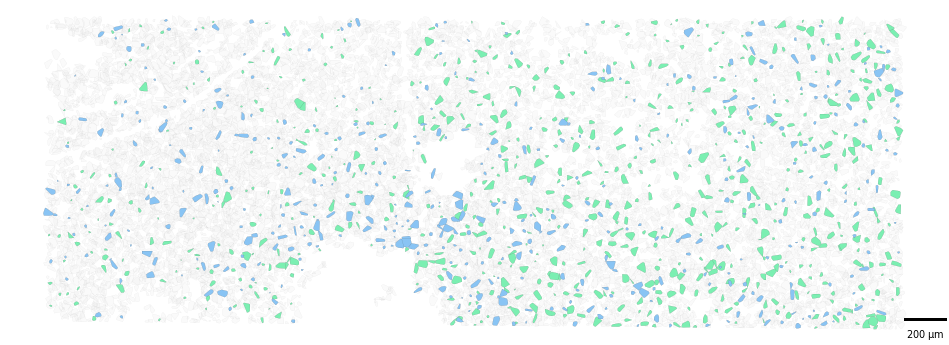

In [15]:
selected = ['preOPC-like', 'OPC-like 2']
sp.pl.plot_polygons(
    adata,
    'SL001B',
    cluster_key= 'm-states',
    clusters = selected, 
    grey_clusters=grey,
    palette = palette,
    show_axis=False,
    area_min_size=10,
    alpha=1,
    figsize=(10,10),
    xlim = (7000, 11000),
    ylim = (1000, 3000), 
    save=True,
    savepath='figures/SL001B_OPC-preOPC.svg'
)

In [16]:
sadata = adata[adata.obs.Sample == 'SL001A']

INFO:root:First filter, 63392 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 13603 cells left


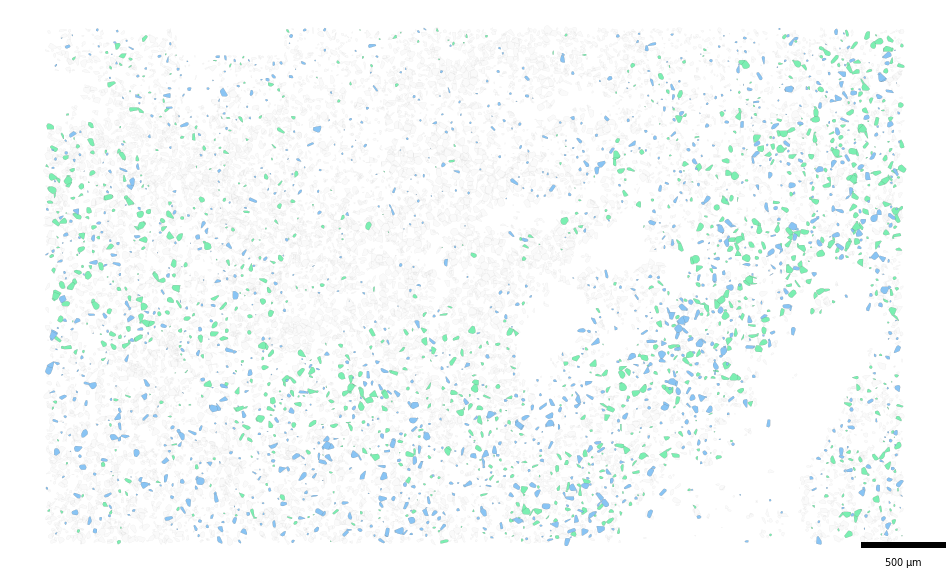

In [17]:
selected = ['preOPC-like', 'OPC-like 2']
sp.pl.plot_polygons(
    adata,
    'SL001A',
    cluster_key= 'm-states',
    clusters = selected, 
    grey_clusters=grey,
    palette = palette,
    show_axis=False,
    area_min_size=1,
    alpha=1,
    #gray_color='#eeeeee',
    alpha_gray=0.25,
    figsize=(10,10),
    xlim = (2500,7500),
    ylim = (3000,6000),
    
    save=True,
    savepath='figures/SL001A_OPC-preOPC.svg'
)

INFO:root:First filter, 157500 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 16181 cells left


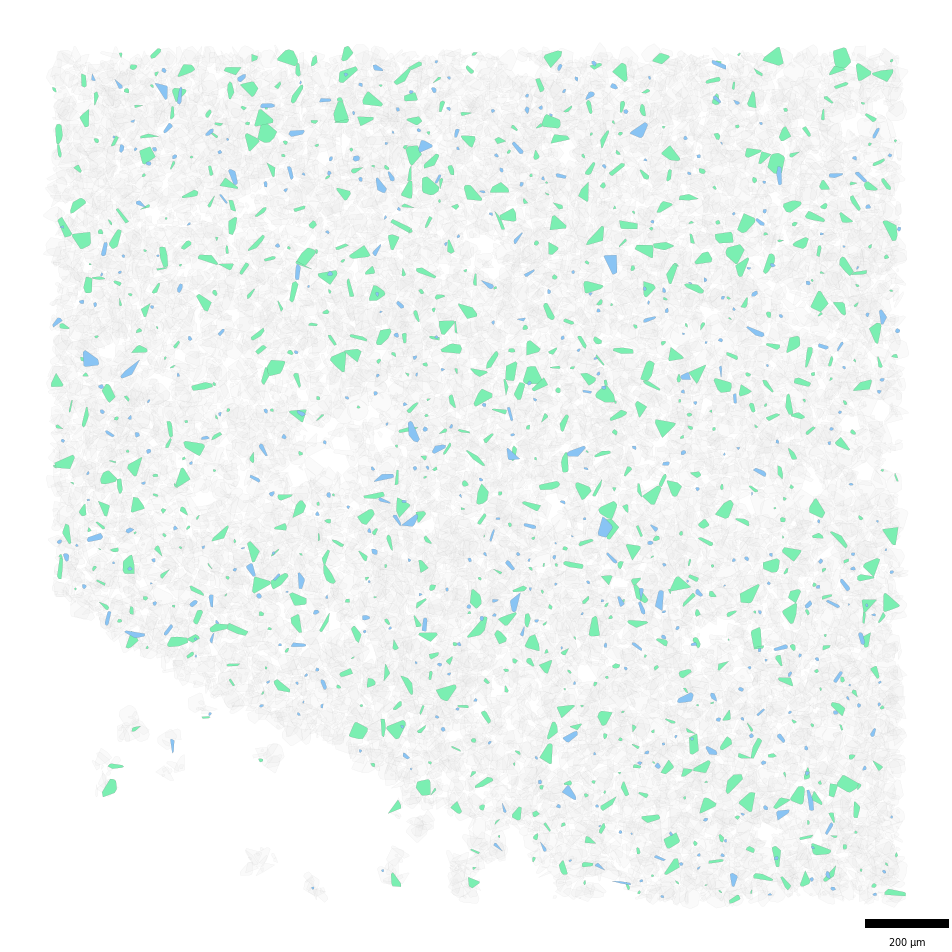

In [18]:
selected = ['preOPC-like', 'OPC-like 2']
sp.pl.plot_polygons(
    adata,
    'SL038',
    cluster_key= 'm-states',
    clusters = selected, 
    xlim=(1000,3000),
    ylim=(1000,3000),
    grey_clusters=grey,
    palette = palette,
    show_axis=False,
    area_min_size=1,
    alpha=1,
    #gray_color='#eeeeee',
    alpha_gray=0.25,
    figsize=(10,10),

    
    save=True,
    savepath='figures/SL038_OPC-preOPC.svg'
)

INFO:root:First filter, 63366 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 12747 cells left


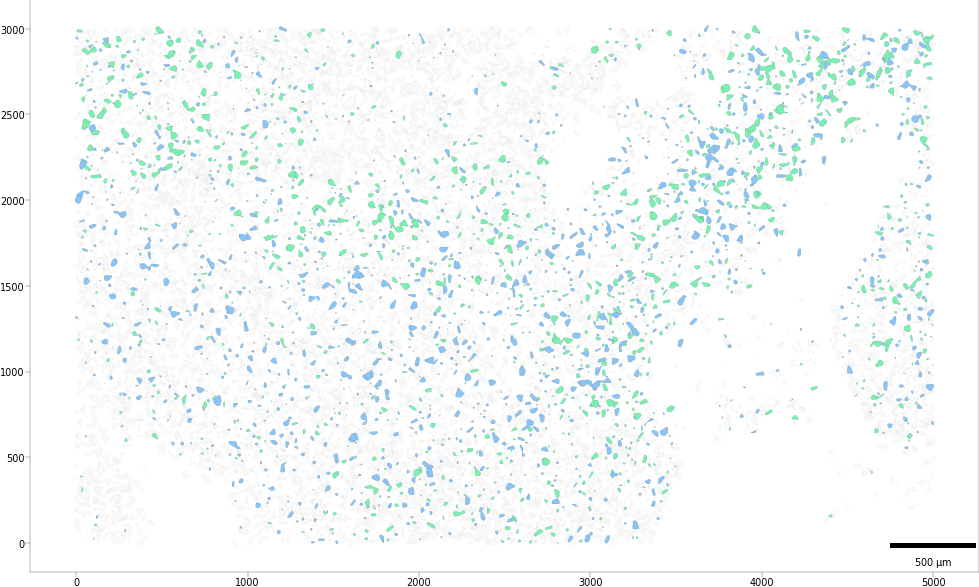

In [19]:
selected = ['preOPC-like','OPC-like 2']
sp.pl.plot_polygons(
    adata,
    'SL001A',
    cluster_key= 'm-states',
    clusters = selected, 
    grey_clusters=grey,
    palette = palette,
    show_axis=True,
    area_min_size=10,
    alpha=1,
    xlim=(2500, 7500),
    ylim = (2000,5000),
    figsize=(10,10),
    #save=True,
    #savepath='figures/SL001A_OPC-preOPC.svg'
)

INFO:root:First filter, 62033 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 12603 cells left


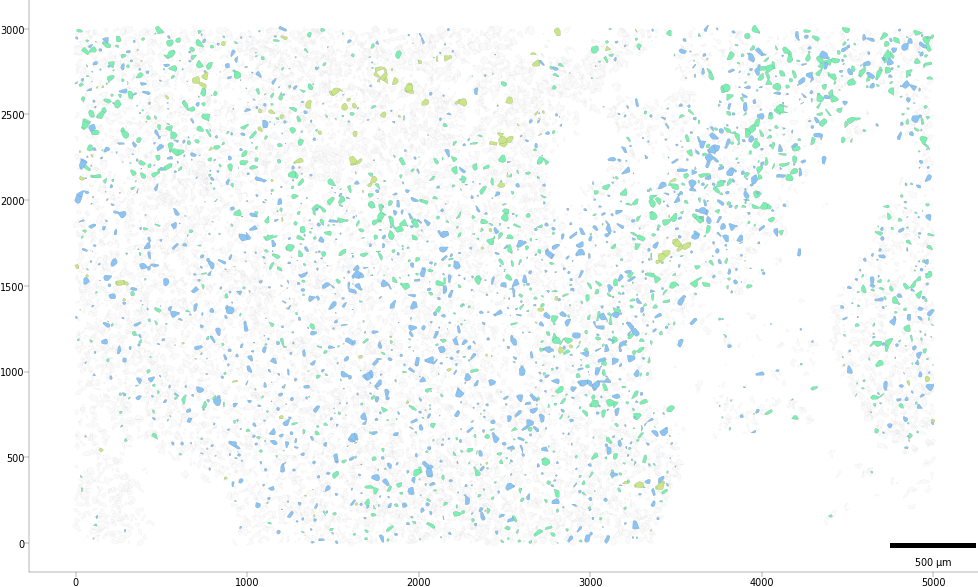

In [12]:
selected = ['preOPC-like 1','OPC-like 2','Endothelial']
sp.pl.plot_polygons(
    adata,
    'SL001A',
    cluster_key= 'm-states3',
    clusters = selected, 
    grey_clusters=grey,
    palette = palette,
    show_axis=True,
    area_min_size=10,
    alpha=1,
    xlim=(2500, 7500),
    ylim = (2000,5000),
    figsize=(10,10),
    #save=True,
    #savepath='figures/SL001A_OPC-preOPC.svg'
)

# SL035B

INFO:root:First filter, 462990 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 79630 cells left


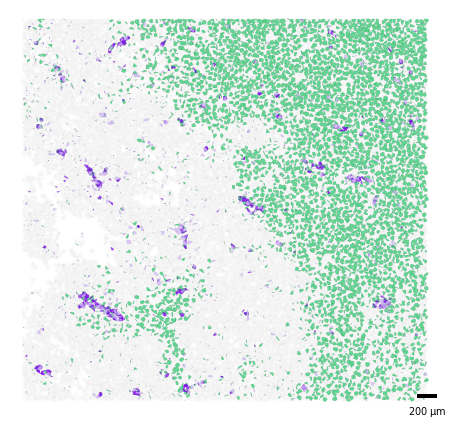

In [25]:
selected = ['AC-like 3','Mural', 'Endothelial']
sp.pl.plot_polygons(
    adata,
    'SL035B',
    cluster_key= 'm-states',
    xlim=(11000,15000),
    ylim=(5000,9000),
    clusters = selected, 
    grey_clusters=grey,
    palette = palette,
    area_min_size=10,
    alpha_gray=0.25,
    linewidth_gray=0,
    figsize=(5,5),
    save=True,
    #show_axis=True,
    savepath='figures/SL0035B_AC-Mural.svg'
)

INFO:root:First filter, 462990 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 5153 cells left


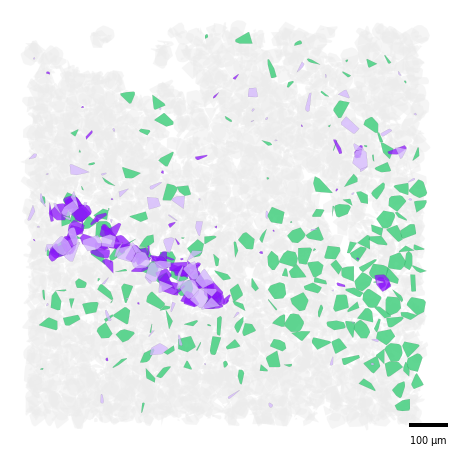

In [26]:
selected = ['AC-like 3' ,'Mural','Endothelial']
sp.pl.plot_polygons(
    adata,
    'SL035B',
    cluster_key= 'm-states',
    xlim=(11500,12500),
    ylim=(5500,6500),
    clusters = selected, 
    grey_clusters=grey,
    alpha_gray=0.5,
    linewidth_gray=0,
    palette = palette,
    area_min_size=10,
    figsize=(5,5),
    save=True,
    show_axis=False,
    savepath='figures/SL0035B_AC-Muralzoom.svg'
)

INFO:root:First filter, 102925 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2933 cells left


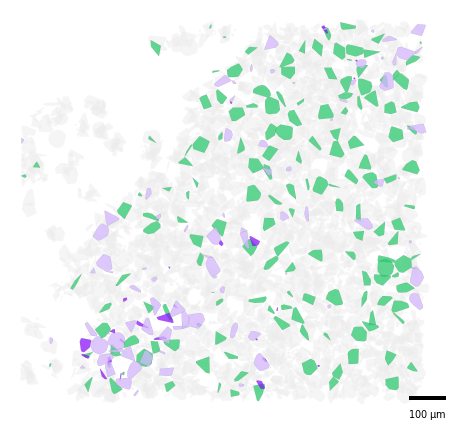

In [27]:
selected = ['AC-like 3' ,'Mural','Endothelial']
sp.pl.plot_polygons(
    adata,
    'SL034',
    cluster_key= 'm-states',
    xlim=(3500,5000),
    ylim=(3000,4000),
    clusters = selected, 
    grey_clusters=grey,
    alpha_gray=0.5,
    linewidth_gray=0,
    palette = palette,
    area_min_size=10,
    figsize=(5,5),
    save=True,
    show_axis=False,
    savepath='figures/SL034_AC-Muralzoom.svg'
)

INFO:root:First filter, 272470 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 7446 cells left


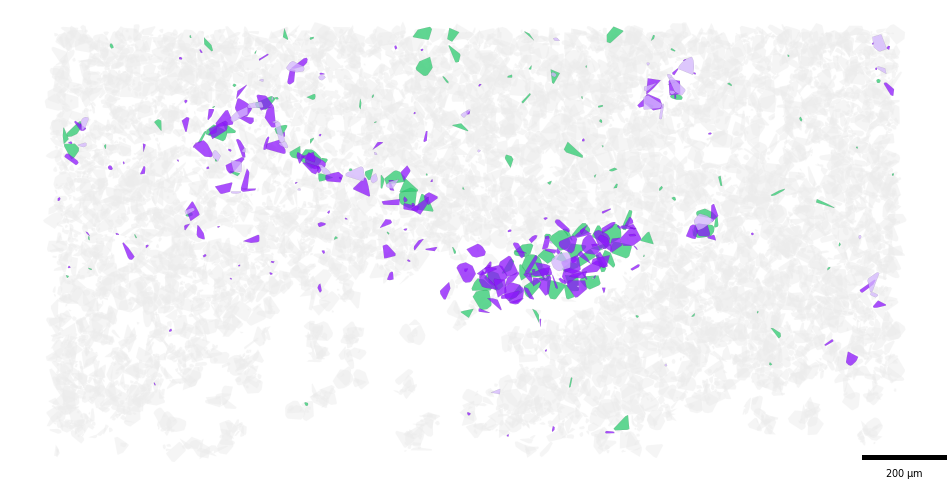

In [28]:
selected = ['AC-like 3' ,'Mural','Endothelial']
sp.pl.plot_polygons(
    adata,
    'SL046C',
    cluster_key= 'm-states',
    xlim=(8000,10000),
    ylim=(1600,2600),
    clusters = selected, 
    grey_clusters=grey,
    alpha_gray=0.5,
    linewidth_gray=0,
    palette = palette,
    area_min_size=10,
    figsize=(10,10),
    save=True,
    show_axis=False,
    savepath='figures/SL046_AC-Muralzoom.svg'
)

INFO:root:First filter, 259590 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 4265 cells left


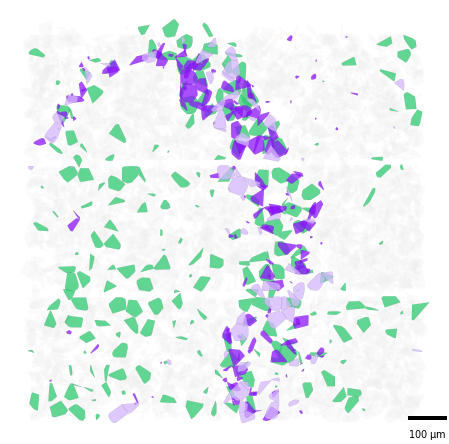

In [29]:
selected = ['AC-like 3' ,'Mural','Endothelial']
sp.pl.plot_polygons(
    adata,
    'SL046B',
    cluster_key= 'm-states',
    xlim=(7500,8500),
    ylim=(6500,7500),
    clusters = selected, 
    grey_clusters=grey,
    alpha_gray=0.25,
    linewidth_gray=0,
    palette = palette,
    area_min_size=10,
    figsize=(5,5),
    save=True,
    show_axis=False,
    savepath='figures/SL046B_AC-Muralzoom.svg'
)